# 10 — Building an architecture you can read

The three notebooks that follow are one story about one model.

| | |
|---|---|
| **10** (here) | Build the pipeline as a graph, and let the compiler tell you where the trainable region begins |
| **11** | Ask the model what is wrong with it *before* spending a sweep on it |
| **12** | Use what every run recorded to decide what to try next |

The setting: a 1-D sensor stream with three regimes — a flat baseline, a
slow drift, and a short burst. Two feature views, each deliberately
blind to one of the three, and a model that has to combine them.

Everything is synthetic and seeded, so you can run this offline and get
the same numbers.

In [1]:
import warnings

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import SVG

import soma
from soma import Filter, Graph

pio.renderers.default = "plotly_mimetype+png"   # interactive here, PNG on GitHub
pio.renderers["png"].scale = 2
pio.renderers["png"].width = 950
warnings.filterwarnings("ignore", message="Full backward hook is firing")

import campaign   # the shared generator + filters, next to this notebook

## 10.1 — The stream

Three regimes over a 128-sample window. `drift` adds a slow rising ramp;
`burst` adds a short high-frequency packet somewhere in the middle.

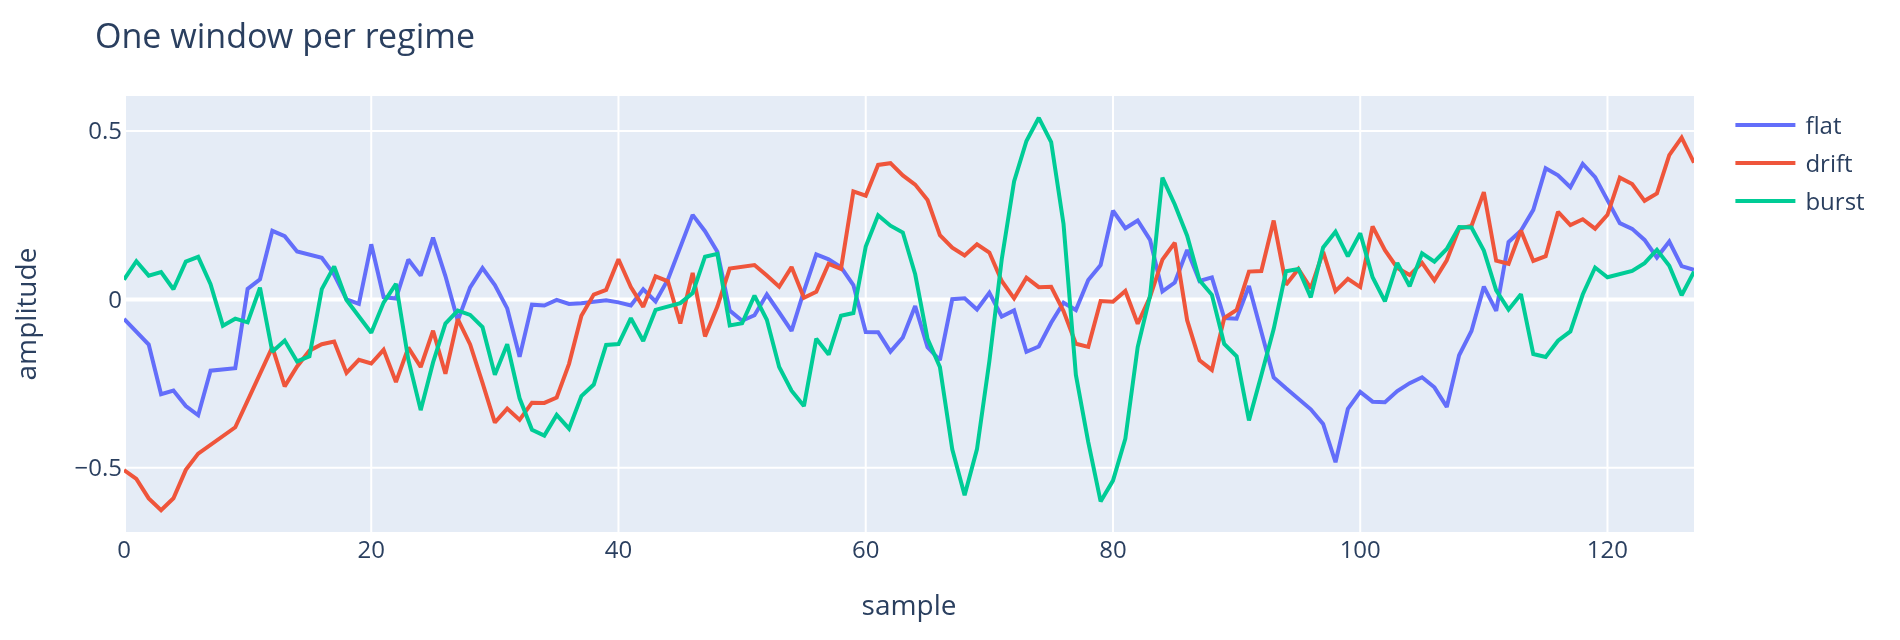

In [2]:
X, y = campaign.make_windows(512, seed=0)
Xtr, ytr, Xva, yva = campaign.split(X, y)

fig = go.Figure()
for cls, name in enumerate(campaign.CLASSES):
    fig.add_scatter(y=X[np.argmax(y == cls)], name=name, mode="lines")
fig.update_layout(
    title="One window per regime", height=320,
    xaxis_title="sample", yaxis_title="amplitude",
    margin=dict(t=48, b=40, l=48, r=16),
)
fig

## 10.2 — Two views, each blind to one regime

The **spectral** view drops the lowest FFT bins — which is exactly where
a linear drift puts its energy. The **shape** view mean-pools into 16
bins, which averages a fast oscillation away.

So neither view can classify all three regimes on its own. That is not a
contrivance for the tutorial; it is the ordinary situation that makes a
multi-branch model worth building, and in notebook 11 it is what makes a
wiring bug between the branches *cost* something.

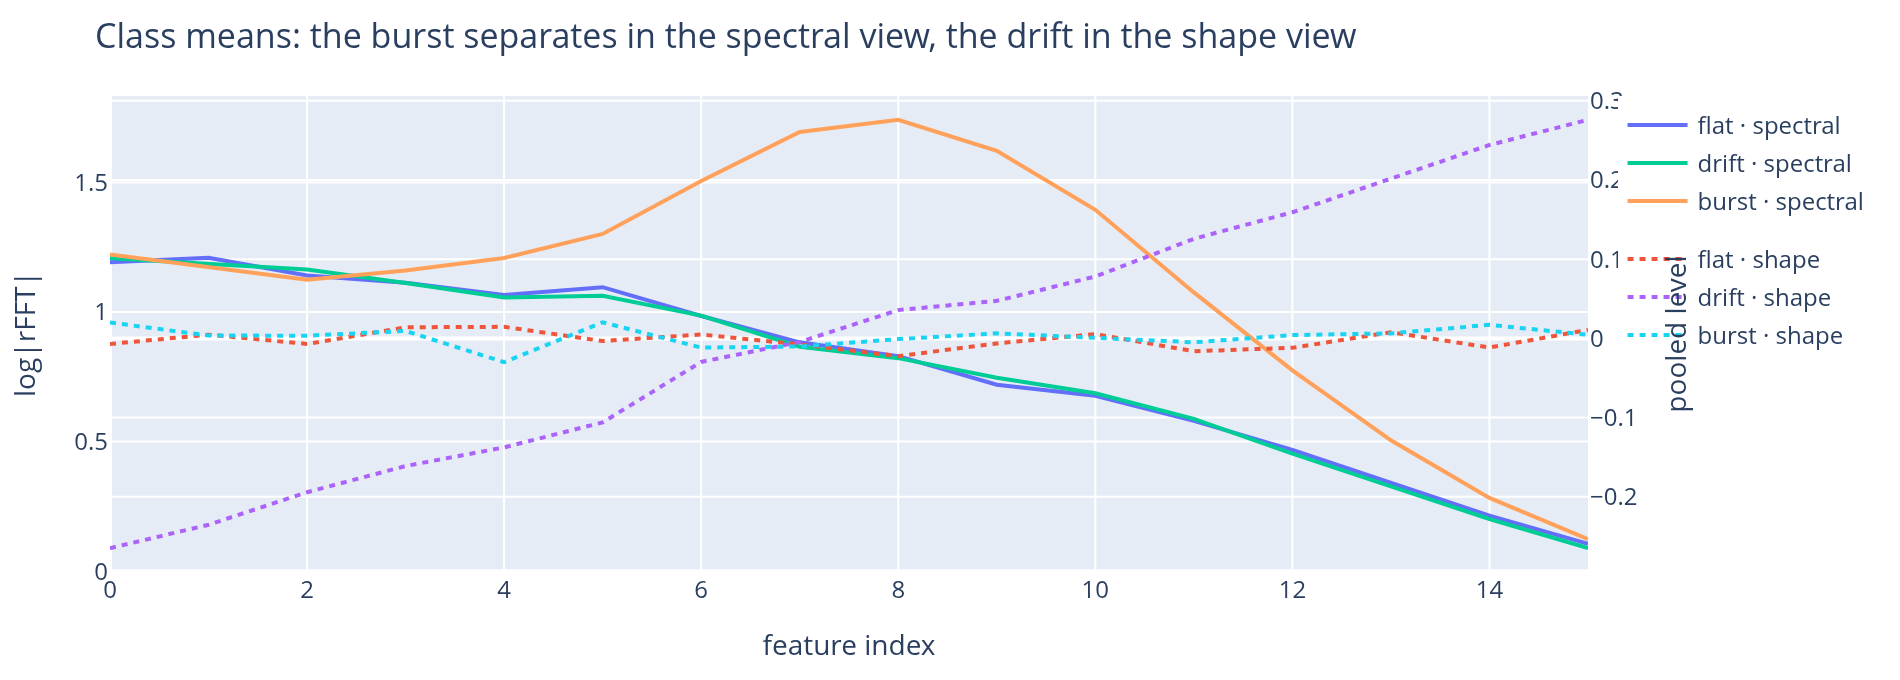

In [3]:
spec, shape = campaign.spectral_view(X), campaign.shape_view(X)

fig = go.Figure()
for cls, name in enumerate(campaign.CLASSES):
    fig.add_scatter(y=spec[y == cls].mean(0), name=f"{name} · spectral",
                    mode="lines", legendgroup="s")
    fig.add_scatter(y=shape[y == cls].mean(0), name=f"{name} · shape",
                    mode="lines", legendgroup="h", line=dict(dash="dot"), yaxis="y2")
fig.update_layout(
    title="Class means: the burst separates in the spectral view, the drift in the shape view",
    height=340, xaxis_title="feature index",
    yaxis=dict(title="log|rFFT|"), yaxis2=dict(title="pooled level", overlaying="y", side="right"),
    margin=dict(t=48, b=40, l=48, r=48),
)
fig

In [4]:
# A nearest-centroid probe: how much does each view carry alone?
def centroid_accuracy(F):
    tr, va = F[:384], F[384:]
    mu = np.stack([tr[ytr == k].mean(0) for k in range(3)])
    pred = np.argmin(((va[:, None, :] - mu[None]) ** 2).sum(-1), axis=1)
    return (pred == yva).mean()

for name, F in [("spectral only", spec), ("shape only", shape),
                ("both", campaign.features(X))]:
    print(f"{name:14s} {centroid_accuracy(F):.2f}")

spectral only  0.64
shape only     0.65
both           0.98


## 10.3 — Filters

A `Filter` is two methods. `fit(x, y)` learns state and returns it as a
dict; `forward(x, state)` transforms. They are cached independently, so
`fit` runs once per (configuration, data) and never again.

Filters defined in a notebook **must** declare `_cache_version`: a
headless kernel has no source to hash, so without it soma falls back to
cloudpickle and warns.

In [5]:
class Detrend(Filter):
    """Remove each window's linear trend — a stateless preprocessing step."""
    _cache_version = "nb10-detrend-v1"

    def fit(self, x, y=None):
        return {}

    def forward(self, x, state):
        a = np.asarray(x, dtype=float)
        t = np.linspace(-1, 1, a.shape[1])
        coef = (a * t).sum(1, keepdims=True) / (t * t).sum()
        return (a - coef * t).tolist()


class Spectral(Filter):
    _cache_version = "nb10-spectral-v1"

    def fit(self, x, y=None):
        return {}

    def forward(self, x, state):
        return campaign.spectral_view(np.asarray(x)).tolist()


class Shape(Filter):
    _cache_version = "nb10-shape-v1"

    def fit(self, x, y=None):
        return {}

    def forward(self, x, state):
        return campaign.shape_view(np.asarray(x)).tolist()


class Fuse(Filter):
    """Fan-in: `x` arrives as {node_id: branch_output}.

    Concatenated spectral-first, which fixes the channel layout that
    notebook 11's ChannelConfig.groups refers to by index.
    """
    _cache_version = "nb10-fuse-v1"

    def fit(self, x, y=None):
        return {}

    def forward(self, x, state):
        return np.concatenate([np.asarray(x["spectral"]),
                               np.asarray(x["shape"])], axis=1).tolist()


class Standardize(Filter):
    """The only fitted node: it learns the training mean and scale."""
    _cache_version = "nb10-standardize-v1"

    def fit(self, x, y=None):
        a = np.asarray(x, dtype=float)
        return {"mean": a.mean(0).tolist(), "std": (a.std(0) + 1e-9).tolist()}

    def forward(self, x, state):
        a = np.asarray(x, dtype=float)
        return ((a - np.asarray(state["mean"])) / np.asarray(state["std"])).tolist()

## 10.4 — The graph

`>>` chains, `|` forks, and a filter after a fork collects it.

The node ids come from the class names, lowercased — `Spectral()`
becomes `spectral`. That is not cosmetic here: it is exactly the key
`Fuse` reads out of its fan-in dict. Rename the class and you have
renamed the key. (`g.node("spectral", Spectral())` sets the id
explicitly if you would rather not have that coupling; notebook 01
covers both forms.)

Evaluating the graph draws it.

In [6]:
g_prep = Graph.somatize(
    Detrend() >> (Spectral() | Shape()) >> Fuse() >> Standardize()
)
print(g_prep.filter_ids())
g_prep

['detrend', 'shape', 'spectral', 'fuse', 'standardize']


Graph(5 nodes, 5 edges, fitted=false)

## 10.5 — Ask the compiler before you run

`compile()` reports what it can prove about the plan without executing
it: how many nodes, how many are already cached, where the parallel
branches are, and — in `differentiable` mode — every point where
gradient flow is interrupted.

In [7]:
g_prep.compile(mode="differentiable")

{'total_nodes': 5,
 'cached_nodes': 0,
 'parallel_branches': 2,
 'diagnostics': [{'node': 'detrend',
   'level': 'warning',
   'message': 'gradient flow interrupted at `detrend` (Trainable). Gradients from upstream will not reach downstream filters through this node.'},
  {'node': 'detrend',
   'level': 'info',
   'message': 'cache lookups are resolved at runtime per node (key = hash(config + state + input)); the compiled plan contains no Cached nodes'}],
 'plan_text': 'Sequence:\n  Execute(detrend)\n  Parallel:\n    Execute(shape)\n    Execute(spectral)\n  Execute(fuse)\n  Execute(standardize)\n',
 'plan_mermaid': 'graph TD\n    detrend[detrend]\n    fork_0{{fork}}\n    detrend --> fork_0\n    shape[shape]\n    fork_0 --> shape\n    spectral[spectral]\n    fork_0 --> spectral\n    fuse[fuse]\n    standardize[standardize]\n    fuse --> standardize\n',
 'plan_svg': '<svg xmlns="http://www.w3.org/2000/svg" width="426" height="122" viewBox="0 0 426 122" font-family="system-ui, -apple-system, \'Segoe UI\', sans-serif"><defs><marker id="soma-arrow" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M 0 1 L 9 5 L 0 9 z" fill="#898781"/></marker></defs><path d="M 97.2 89.0 C 125.2 89.0, 125.2 89.0, 153.2 89.0" fill="none" stroke="#898781" stroke-width="1.5" marker-end="url(#soma-arrow)"/><path d="M 225.2 89.0 C 273.0 89.0, 273.0 33.0, 320.8 33.0" fill="none" stroke="#898781" stroke-width="1.5" marker-end="url(#soma-arrow)"/><path d="M 225.2 89.0 C 273.0 89.0, 273.0 89.0, 320.8 89.0" fill="none" stroke="#898781" stroke-width="1.5" marker-end="url(#soma-arrow)"/><path d="M 88.0 33.0 C 120.6 33.0, 120.6 33.0, 153.2 33.0" fill="none" stroke="#898781" stroke-width="1.5" marker-end="url(#soma-arrow)"/><rect x="16.0" y="16.0" width="72.0" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><text x="52.0" y="37.5" font-size="13" fill="#0b0b0b" text-anchor="middle">fuse</text><rect x="153.2" y="16.0" width="111.6" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><text x="209.0" y="37.5" font-size="13" fill="#0b0b0b" text-anchor="middle">standardize</text><rect x="16.0" y="72.0" width="81.2" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><text x="56.6" y="93.5" font-size="13" fill="#0b0b0b" text-anchor="middle">detrend</text><rect x="153.2" y="72.0" width="72.0" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><path d="M 153.2 89.0 l 6 -6 M 153.2 89.0 l 6 6 M 225.2 89.0 l -6 -6 M 225.2 89.0 l -6 6" stroke="#c3c2b7" stroke-width="1.2" fill="none"/><text x="189.2" y="93.5" font-size="13" fill="#0b0b0b" text-anchor="middle">fork</text><rect x="320.8" y="16.0" width="72.0" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><text x="356.8" y="37.5" font-size="13" fill="#0b0b0b" text-anchor="middle">shape</text><rect x="320.8" y="72.0" width="88.8" height="34.0" rx="6.0" fill="#fcfcfb" stroke="#c3c2b7" stroke-width="1.4"/><text x="365.2" y="93.5" font-size="13" fill="#0b0b0b" text-anchor="middle">spectral</text></svg>'}

Every one of those diagnostics is correct: these are numpy
filters, nothing here is differentiable, and a gradient could not cross
any of them.

That is the argument for the split this notebook is building toward.
Preprocessing is a **fit-once, cache-forever** stage; the trainable
region starts after it. Keeping them in separate graphs means the sweep
in notebook 11 and the four variants in notebook 12 all reuse one cached
feature computation instead of recomputing it every time.

One more constraint worth knowing before notebook 11: the native
training loop walks filters in topological order and threads one
output into the next, so **a differentiable graph has to be a chain**.
Branching still happens — inside a node, in its own `nn.Module`, which
is exactly where `DualViewEncoder` puts it.

In [8]:
with g_prep.track_run("features", kind="fit", tags=["pulse-lab"]) as run:
    g_prep.fit(Xtr.tolist())
    Ftr = np.asarray(g_prep.forward(Xtr.tolist()))
    Fva = np.asarray(g_prep.forward(Xva.tolist()))

print("train features", Ftr.shape, " validation features", Fva.shape)
print("run:", run.id)

train features (384, 32)  validation features (128, 32)
run: run_20260804T003503_da2a


## 10.6 — The same graph, annotated with what happened

`RunView` reads the run directory. Nothing here re-runs anything — the
diagram is the topology from `graph.json` with per-node timings, cache
tiers and status folded in.

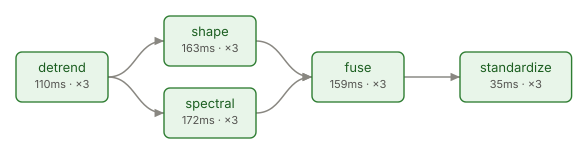

In [9]:
view = soma.RunView(run.dir)
SVG(view.to_svg())

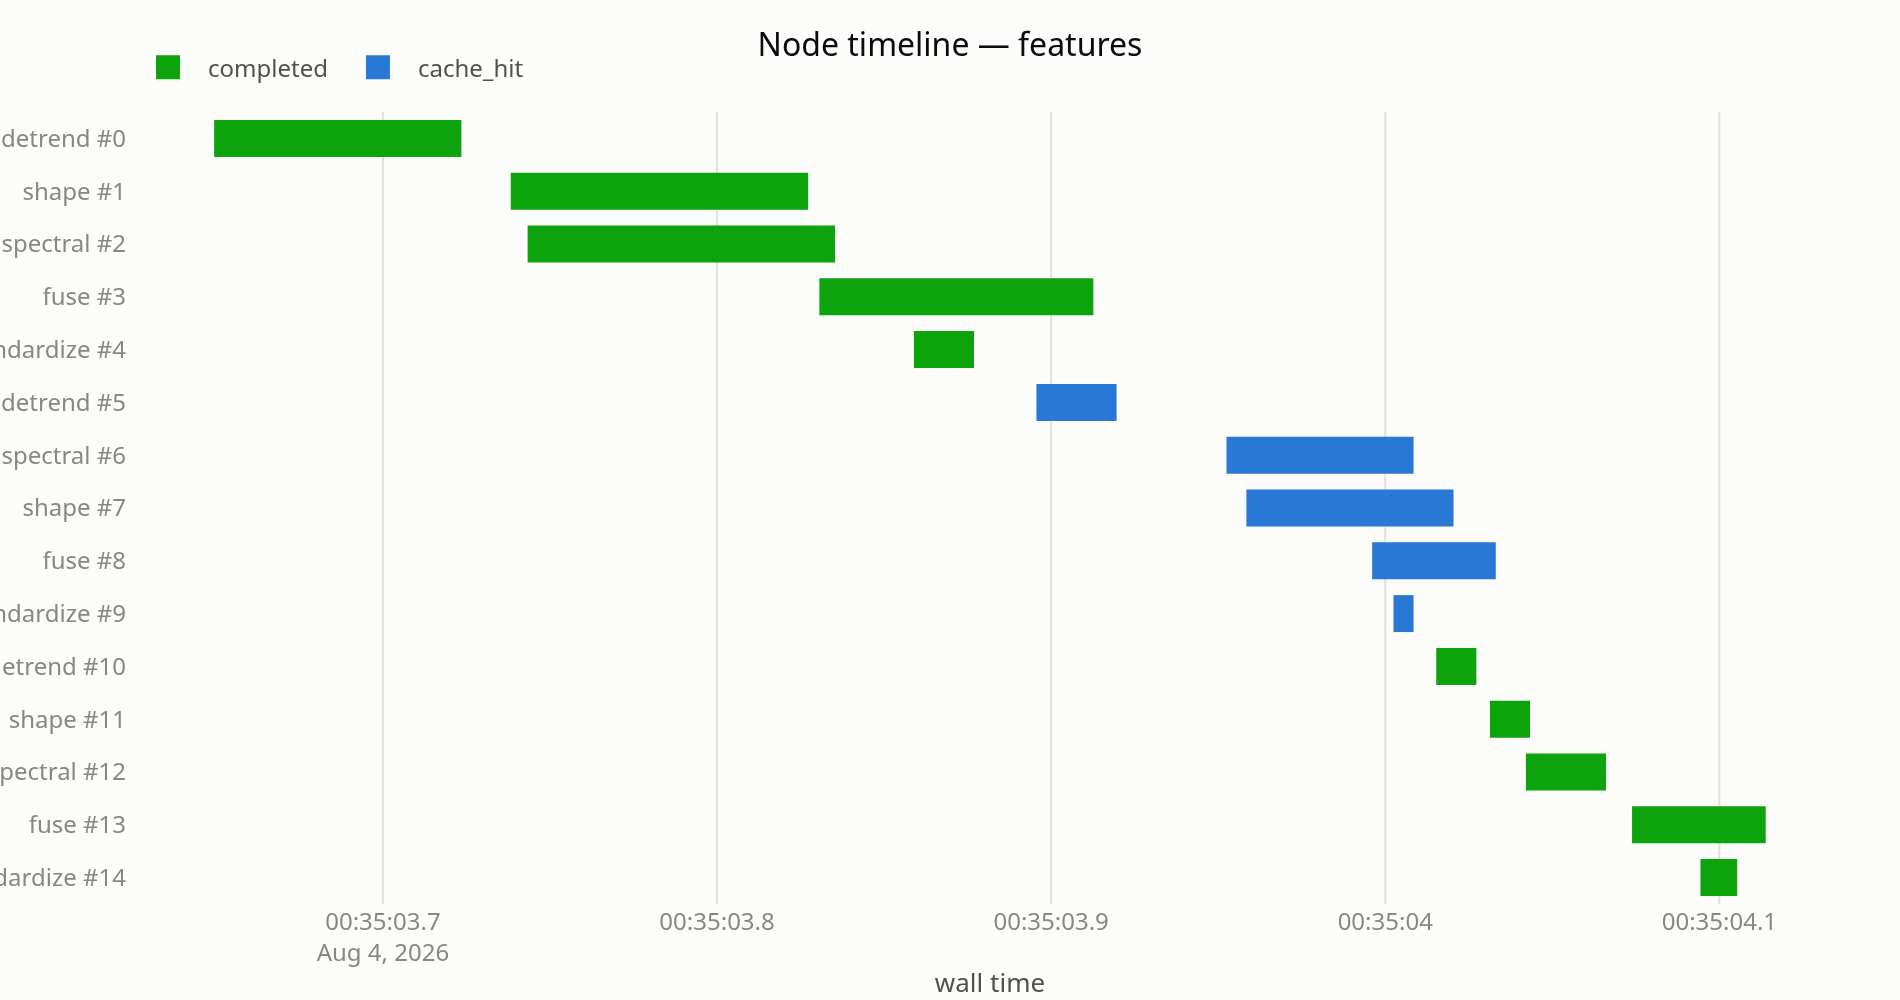

In [10]:
view.plot_gantt()

## 10.7 — The cache

Same configuration, same data, same result — and no recomputation. This
is what pays for the sweep in notebook 11 and the variants in 12.

In [11]:
g2 = Graph.somatize(
    Detrend() >> (Spectral() | Shape()) >> Fuse() >> Standardize()
)

with g2.track_run("features-again", kind="fit", tags=["pulse-lab"]) as run2:
    g2.fit(Xtr.tolist())
    _ = g2.forward(Xtr.tolist())

activity = soma.RunView(run2.dir).cache_activity()
print(f"hits {activity['hits']}   misses {activity['misses']}")

hits 10   misses 0


In [12]:
soma.runs()

run id,kind,state,created,duration,name
run_20260804T003506_8975,fit,completed,2026-08-04 00:35:06,0.4s,features-again
run_20260804T003503_da2a,fit,completed,2026-08-04 00:35:03,0.6s,features


## What's next

Notebook 11 puts a model on top of these features — and finds four
things wrong with it before tuning a single hyperparameter.